# Fake News Detection — Text Cleaning & Preprocessing

Clean the raw text (lowercase, strip URLs / punctuation / digits, remove stopwords, apply Porter stemming) and save a tidy `clean_text` + `label` dataset for modeling.

## 1. Imports & Load Raw Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
from utils import load_data, clean_text
sns.set_style('whitegrid')
%matplotlib inline

In [2]:
df = load_data()
print('Raw shape:', df.shape)
df.head()

Raw shape: (6335, 2)


,content,label
0,You Can Smell Hillary’s Fear. Daniel Greenfiel...,FAKE
1,Watch The Exact Moment Paul Ryan Committed Pol...,FAKE
2,Kerry to go to Paris in gesture of sympathy. U...,REAL
3,Bernie supporters on Twitter erupt in anger ag...,FAKE
4,The Battle of New York: Why This Primary Matte...,REAL


## 2. Handle Missing / Duplicate Rows

In [3]:
print('Missing:', df.isnull().sum().sum())
print('Duplicates:', df.duplicated().sum())
df = df.dropna(subset=['content', 'label']).drop_duplicates().reset_index(drop=True)
print('After cleanup:', df.shape)

Missing: 0
Duplicates: 29


After cleanup: (6306, 2)


## 3. Apply Text Cleaning

In [4]:
# clean_text: lowercase, strip urls/html/punctuation/digits, remove stopwords, Porter-stem
print('Example BEFORE:'); print(repr(df['content'].iloc[0][:300]))
df['clean_text'] = df['content'].astype(str).apply(clean_text)
print('\nExample AFTER:'); print(repr(df['clean_text'].iloc[0][:300]))

Example BEFORE:
'You Can Smell Hillary’s Fear. Daniel Greenfield, a Shillman Journalism Fellow at the Freedom Center, is a New York writer focusing on radical Islam. \nIn the final stretch of the election, Hillary Rodham Clinton has gone to war with the FBI. \nThe word “unprecedented” has been thrown around so often t'



Example AFTER:
'smell hillari fear daniel greenfield shillman journal fellow freedom center new york writer focus radic islam final stretch elect hillari rodham clinton gone war fbi word unpreced thrown around often elect ought retir still unpreced nomine major polit parti go war fbi exactli hillari peopl done coma'


## 4. Drop Rows That Became Empty After Cleaning

In [5]:
before = len(df)
df = df[df['clean_text'].str.strip().str.len() > 0].reset_index(drop=True)
print(f'Dropped {before - len(df)} rows that were empty after cleaning')
print('Remaining:', len(df))

Dropped 0 rows that were empty after cleaning
Remaining: 6306


## 5. Cleaned Text Length Comparison

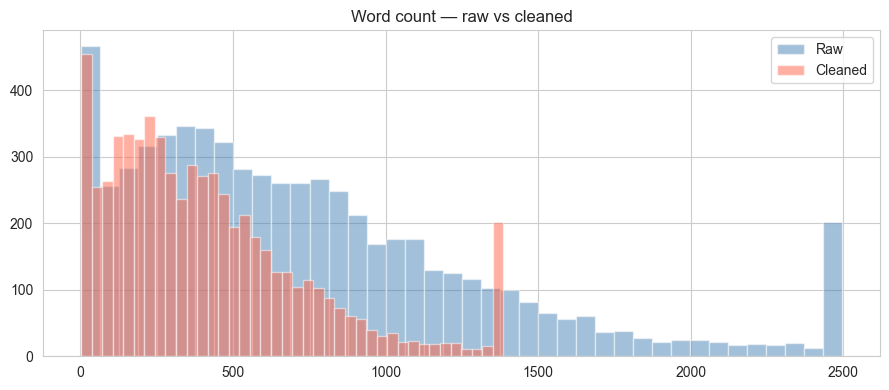

Mean words raw : 786.8
Mean words clean: 436.8


In [6]:
df['raw_words'] = df['content'].astype(str).str.split().str.len()
df['clean_words'] = df['clean_text'].str.split().str.len()
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df['raw_words'].clip(upper=df['raw_words'].quantile(0.97)), bins=40, alpha=0.5, label='Raw', color='steelblue')
ax.hist(df['clean_words'].clip(upper=df['clean_words'].quantile(0.97)), bins=40, alpha=0.5, label='Cleaned', color='tomato')
ax.set_title('Word count — raw vs cleaned'); ax.legend()
plt.tight_layout(); plt.show()
print('Mean words raw :', round(df['raw_words'].mean(), 1))
print('Mean words clean:', round(df['clean_words'].mean(), 1))

## 6. Encode Label

In [7]:
# Map label to integer codes
df['label'] = df['label'].astype('category')
label_mapping = dict(enumerate(df['label'].cat.categories))
df['label'] = df['label'].cat.codes
print('Label mapping:', label_mapping)

Label mapping: {0: 'FAKE', 1: 'REAL'}


## 7. Save Cleaned Dataset

In [8]:
out = df[['clean_text', 'label']].copy()
out.to_csv('data/fake_news_cleaned.csv', index=False)
print('Saved -> data/fake_news_cleaned.csv', out.shape)
out.head()

Saved -> data/fake_news_cleaned.csv (6306, 2)


,clean_text,label
0,smell hillari fear daniel greenfield shillman ...,0
1,watch exact moment paul ryan commit polit suic...,0
2,kerri go pari gestur sympathi secretari state ...,1
3,berni support twitter erupt anger dnc tri warn...,0
4,battl new york primari matter primari day new ...,1
